# Long logic sentences and FOL error suite: row-level source re-verification (`data.py`)

This artifact is a **held-out meta-evaluation set for NL→FOL faithfulness metrics**. Each row pairs a
natural-language sentence with a candidate first-order-logic formula and a label that says whether the formula is
faithful to the sentence. There are two tables:

* **PERTURB** (`perturb_suite`, complete): 4,234 typed mutants of trusted reference formulas (label `ERROR`, one
  error operator each: NEG, REV, QUANT, RESTR, CONN, MOVE, DROP, ADD, SWAP, BIND, MEANING_RENAME, at DOWN/UP
  polarity positions). There are also 868 meaning-preserving controls (label `CORRECT`: RENAME_SYN / RENAME_NONCE,
  REORDER, CONTRAPOSITIVE). z3 has checked every mutant: it is non-equivalent to every accepted reading, and every
  control is equivalent to its base.
* **R_COMP** (`rcomp_sentences`): 350 long templated sentences (≥25 words, ≥3 conditions, an
  unless/except/provided-that/only-if clause). Their weak and strong references come from the template, built from
  a lexicon of atoms mined from verified FOLIO/MALLS formulas. *The LLM audit steps are still pending, so R_COMP
  must not be used for metric claims yet.*

`data.py` is the **last step of the build pipeline**. It takes the assembled groups (`work/assembled.json`) and
**re-checks every row against the public sources it came from**:
FOLIO-v2 train, folio-refined, MALLS-v0.1 and the trusted/repaired references of an earlier dataset "E". It
also re-runs the exclusion screen against FOLIO/MALLS validation/test data and Logic-LM outputs. The results go
into `metadata_source_verified` / `metadata_source_file` / `metadata_verify_notes` (rows are never dropped), and
the script writes `full_data_out.json` + `adjudicator_check_out.json`.

**This demo** runs the original `data.py` code on `mini_demo_data.json`, a curated subset with 100 rows from 13 base
sentences. The subset covers all four base sources and every operator/control type. The file also holds exactly
the source records needed to verify those rows. The exclusion-screen sources are included in full (text fields
only).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (the only third-party import of data.py)
_pip('loguru==0.7.3')

# numpy, matplotlib — pre-installed on Colab, install locally only (used by the visualization cell)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')

In [2]:
# ---- original import block of data.py (unchanged)
from __future__ import annotations

import csv
import hashlib
import json
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

from loguru import logger

# ---- additional imports for the notebook (visualization)
import matplotlib.pyplot as plt
import numpy as np

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-2/dataset-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: v for k, v in data["metadata"].items() if k != "base_sentence_order"})
print("source record counts:", {k: (len(v) if isinstance(v, list) else {m: len(x) for m, x in v.items()})
                                for k, v in data["sources"].items()})

{'description': "Curated demo subset of art_zcwCQgTqk6DN (R_COMP + PERTURB NL->FOL faithfulness suite): data.py's input rows (work/assembled.json subset, grouped by base sentence), the lexicon entries they use, and exactly the public source records data.py re-verifies them against.", 'n_rows': {'rcomp_sentences': 3, 'perturb_suite': 93, 'adjudicator_check': 4}, 'full_counts': {'rcomp_sentences': 350, 'perturb_suite': 5102, 'adjudicator_check': 60}, 'source_subsets': 'folio_v2_train / folio_refined_train / malls_train / E_heldout_sentences: only records matching the chosen rows; exclusion-screen sources: complete (text fields only)'}
source record counts: {'folio_v2_train': 52, 'folio_refined_train': 52, 'malls_train': 10, 'E_heldout_sentences': 16, 'folio_v2_validation': 203, 'folio_refined_validation': 203, 'dsav_folio_curated': 275, 'dsav_malls_curated': 100, 'malls_test': 1000, 'logiclm_folio_dev': {'gpt-3.5-turbo': 204, 'gpt-4': 204, 'text-davinci-003': 204}}


## Configuration

`data.py` has no training-style hyperparameters: it is a deterministic verification pass. Its size parameter is
how many rows it processes. In the demo that is **`MAX_BASES`**, the number of base sentences (from the curated
subset) whose rows are verified. For each base kept, the demo keeps all of its rows: its perturb mutants and
controls, its R_COMP sentence row (if it is an R_COMP base) and its adjudicator check items. This keeps
cross-row checks consistent. The curated file holds 13 bases (100 rows). The original script processes all
5,452 rows of `work/assembled.json`, which is a 14 MB file plus about 36 MB of source files.

In [5]:
MAX_BASES = 13            # base sentences to verify (curated subset has 13; original: all bases in work/assembled.json)
N_WARN_SHOWN = 10         # original: bad[:10] unverified rows logged as warnings
SIZE_WARN_BYTES = 30e6    # original: warn if full_data_out.json > 30 MB

## Setup: paths and logging

In the original script `ROOT` is the artifact directory and `T = ROOT/temp/datasets` holds the source files. In
the notebook the sources come from `data["sources"]` (see `load_sources` below), so `ROOT` is just the current
directory. The outputs and `logs/data.log` are written there.

In [6]:
ROOT = Path(".").resolve()   # original: Path(__file__).resolve().parent
SRC = data["sources"]        # notebook: replaces the files under T = ROOT / "temp" / "datasets"
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

2

## Text normalisation and hashing helpers

These helpers are exact copies of dataset E's `select_sentences.py` helpers:

* `norm` lower-cases the text, unifies quotes, turns non-alphanumerics into spaces and collapses whitespace.
  It is the key used to match a sentence across sources.
* `h` is the SHA-1 of the normalised text. It is used for the exclusion screen.
* `split_sents` splits a passage into sentences, so that every sentence of a validation/test passage is also screened.
* `fsq` is the formula comparison key: the formula with all whitespace removed.

In [7]:
# ---- exact copies of dataset E's src_e/select_sentences.py helpers (kept standalone so data.py needs no z3)
def norm(s: str) -> str:
    s = s.lower().replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def h(s: str) -> str:
    return hashlib.sha1(norm(s).encode()).hexdigest()


def split_sents(block: str) -> list[str]:
    return [p.strip() for p in re.split(r"(?<=[.!?])\s+|\n+", block) if p.strip()]


def jl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]


def fsq(f: str) -> str:
    """Formula comparison key: whitespace removed."""
    return re.sub(r"\s+", "", f or "")

## Loading the public sources into lookup tables

`load_sources` builds the lookup tables that every check uses:

| key | built from | used for |
|---|---|---|
| `folio_train_premises` | FOLIO-v2 train premises (normalised) | a text is a genuine FOLIO training premise |
| `refined` | folio-refined train: premise text → set of its formulas (only stories with 1:1 NL/FOL alignment) | the formula is the refined FOLIO formula for that premise |
| `malls_train` | MALLS-v0.1 train: text → set of formulas | a MALLS text/formula pair is genuine |
| `exclusion` | hashes of FOLIO-v2/folio-refined validation, the curated DSAV-UNIUD FOLIO/MALLS subsets, MALLS test and Logic-LM FOLIO-dev contexts/questions | **screen**: a composed R_COMP sentence must not collide with any held-out evaluation text |
| `E_by_sid` / `E_by_text` | dataset E's `heldout_sentences` (text, reference formula, status, original gold) | tracing perturb bases and lexicon entries to E |

**Notebook change:** each `jl(T / file)`, `csv.DictReader(open(T / file))` or `json.loads((T / file).read_text())`
now reads the same records from `SRC[...]`, which is `data["sources"]`. The loop bodies are unchanged. In the
demo file, the FOLIO/refined/MALLS/E tables hold only the records relevant to the chosen rows, and the exclusion
sources are complete.

In [8]:
def load_sources() -> dict:
    S = {}
    S["folio_train_premises"] = set()
    for r in SRC["folio_v2_train"]:  # original: jl(T / "tasksource__folio" / "folio_v2_train.jsonl")
        for p in r["premises"].split("\n"):
            if p.strip():
                S["folio_train_premises"].add(norm(p))
    refined = defaultdict(set)
    for r in SRC["folio_refined_train"]:  # original: csv.DictReader(open(T / "yfxiao__folio-refined__train.csv", encoding="utf-8"))
        nls = [x for x in r["nl premises"].split("\n") if x.strip()]
        fols = [x for x in r["fol premises"].split("\n") if x.strip()]
        if len(nls) == len(fols):
            for n, f in zip(nls, fols):
                refined[norm(n)].add(fsq(f))
    S["refined"] = refined
    malls = defaultdict(set)
    for r in SRC["malls_train"]:  # original: json.loads((T / "yuan-yang__MALLS-v0__MALLS-v0.1-train.json").read_text())
        malls[norm(r["NL"])].add(fsq(r["FOL"]))
    S["malls_train"] = malls
    ex = set()

    def add(s):
        for x in [s] + split_sents(s):
            if x.strip():
                ex.add(h(x))
    for r in SRC["folio_v2_validation"]:  # original: jl(T / "tasksource__folio" / "folio_v2_validation.jsonl")
        for p in r["premises"].split("\n"):
            add(p)
        add(r["conclusion"])
    for r in SRC["folio_refined_validation"]:  # original: csv.DictReader(open(T / "yfxiao__folio-refined__validation.csv", ...))
        for p in r["nl premises"].split("\n"):
            add(p)
        add(r["nl conclusion"])
    for f in ("dsav_folio_curated",   # original: "DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl"
              "dsav_malls_curated"):  # original: "DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl"
        for r in SRC[f]:  # original: jl(T / f)
            add(r["NL_sentence"])
    for r in SRC["malls_test"]:  # original: json.loads((T / "yuan-yang__MALLS-v0__MALLS-v0.1-test.json").read_text())
        add(r["NL"])
    for m in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
        for r in SRC["logiclm_folio_dev"][m]:  # original: json.loads((T / "logiclm_FOLIO_dev_outputs" / f"FOLIO_dev_{m}.json").read_text())
            add(r["context"])
            add(r["question"].split("?", 1)[-1])
    S["exclusion"] = ex
    hs = SRC["E_heldout_sentences"]  # original: heldout_sentences group of json.loads((T / "E_heldout_dataset1_full_data_out.json").read_text())
    S["E_by_sid"] = {x["metadata_sentence_id"]: {**json.loads(x["input"]), "status": x["output"],
                                                 "orig": x.get("metadata_original_reference_fol")} for x in hs}
    S["E_by_text"] = defaultdict(list)
    for sid, x in S["E_by_sid"].items():
        S["E_by_text"][norm(x["text"])].append(x)
    logger.info(f"sources: {len(S['folio_train_premises'])} FOLIO-v2 train premises, {len(refined)} refined premises, "
                f"{len(malls)} MALLS-train texts, {len(ex)} exclusion hashes, {len(hs)} E heldout sentences")
    return S

## Tracing a lexicon entry to its source

Each R_COMP sentence is composed from lexicon entries. An entry is an atom such as `Surprise(x)` with its verb-phrase
realisations, mined from a verified reference formula. `verify_lexicon_entry` checks three things:
1. the atom's predicate really occurs in the entry's source formula;
2. for a `FOLIO-v2-train_agreed` entry: the source text is a FOLIO-v2 train premise **and** its folio-refined
   formula equals the source formula;
3. for an `E_heldout_*` entry: some E row with that text has that formula and the claimed status. A
   `GOLD_PANEL_OK` entry must also match a MALLS-train NL/FOL record, and a `TRUSTED_AGREED` entry must also match
   FOLIO + folio-refined.

In [9]:
def verify_lexicon_entry(e: dict, S: dict) -> tuple[bool, str, str]:
    n, f = norm(e["source_text"]), fsq(e["source_fol"])
    pred = e["pred"]
    if not re.search(r"(?<![A-Za-z0-9_])" + re.escape(pred) + r"\(", e["source_fol"]):
        return False, "", f"atom {pred} not in source formula"
    if e["source"] == "FOLIO-v2-train_agreed":
        ok = n in S["folio_train_premises"] and f in S["refined"].get(n, set())
        return ok, "tasksource__folio/folio_v2_train.jsonl + yfxiao__folio-refined__train.csv", "" if ok else "FOLIO source mismatch"
    if e["source"].startswith("E_heldout_"):
        rows = [x for x in S["E_by_text"].get(n, []) if fsq(x["reference_fol"]) == f]
        ok = bool(rows) and rows[0]["status"] == e["source"].replace("E_heldout_", "")
        src = "E_heldout_dataset1_full_data_out.json"
        if ok and rows[0]["status"] == "GOLD_PANEL_OK":
            ok = f in S["malls_train"].get(n, set())
            src += " + yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
        elif ok and rows[0]["status"] == "TRUSTED_AGREED":
            ok = n in S["folio_train_premises"] and f in S["refined"].get(n, set())
            src += " + tasksource__folio + yfxiao__folio-refined"
        return ok, src, "" if ok else "E source mismatch"
    return False, "", f"unknown source {e['source']}"

## `main()`, step 1: load the assembled groups, the sources and the lexicon

From here on, the body of the original `main()` is split into one cell per section (the only change: it runs at top
level instead of inside `@logger.catch(reraise=True) def main():`). `A` is the assembled input. The notebook
reads it from `data["assembled"]` instead of `work/assembled.json`, and the lexicon from `data["lexicon"]` instead
of `lexicon.json`. Then the demo keeps the first `MAX_BASES` base sentences (this is the only added line).

In [10]:
A = data["assembled"]  # original: json.loads((ROOT / "work" / "assembled.json").read_text())
S = load_sources()
lex = {x["lexicon_id"]: x for x in data["lexicon"]["entries"]}  # original: json.loads((ROOT / "lexicon.json").read_text())["entries"]
lex_ver = {lid: verify_lexicon_entry(x, S) for lid, x in lex.items()}
logger.info(f"lexicon entries traced to source: {sum(v[0] for v in lex_ver.values())}/{len(lex_ver)}")
G = {g["dataset"]: g["examples"] for g in A["datasets"]}
# notebook: keep only the first MAX_BASES base sentences of the curated subset (all their rows, in every group)
keep_sids = set(data["metadata"]["base_sentence_order"][:MAX_BASES])
G = {k: [e for e in v if e["metadata_sentence_id"] in keep_sids] for k, v in G.items()}
logger.info(f"rows per group: { {k: len(v) for k, v in G.items()} }")
stats = Counter()

16:24:20|INFO   |sources: 85 FOLIO-v2 train premises, 85 refined premises, 10 MALLS-train texts, 2054 exclusion hashes, 16 E heldout sentences


16:24:20|INFO   |lexicon entries traced to source: 18/18


16:24:20|INFO   |rows per group: {'rcomp_sentences': 3, 'perturb_suite': 93, 'adjudicator_check': 4}


## Step 2: verify the R_COMP sentences

For each long composed sentence, the script:
* re-traces every lexicon entry the sentence uses (`metadata_lexicon_ids`) to its source (see above);
* **screens** the sentence: its hash must not be in the exclusion set built from FOLIO/MALLS validation/test and
  Logic-LM outputs, so it can't leak from those public evaluation sets;
* checks that the default `reference_fol` is the **weak** (exception-as-condition) reading.

It also stores the weak reading of each sentence in `rc_weak`, because the R_COMP-based perturb rows in step 3
are checked against it.

In [11]:
# ---- rcomp_sentences
rc_weak = {}
for e in G["rcomp_sentences"]:
    inp = json.loads(e["input"])
    rc_weak[e["metadata_sentence_id"]] = inp["reference_fol_weak"]
    notes = [f"{lid}: {lex_ver[lid][2]}" for lid in e["metadata_lexicon_ids"] if not lex_ver[lid][0]]
    if h(inp["text"]) in S["exclusion"]:
        notes.append("screen hash collision")
    if inp["reference_fol"] != inp["reference_fol_weak"]:
        notes.append("reference_fol != weak reading")
    e["metadata_source_verified"] = not notes
    e["metadata_source_file"] = "; ".join(sorted({lex_ver[lid][1] for lid in e["metadata_lexicon_ids"] if lex_ver[lid][1]}))
    e["metadata_verify_notes"] = notes
    stats[f"rcomp_sentences_verified_{not notes}"] += 1

## Step 3: verify the PERTURB suite (mutants and controls)

For every perturb row, the script:
* recomputes `item_id = sha1(system | norm(text) | candidate_fol)[:16]` (dataset E's recipe) and compares it;
* checks that the **base** (text + reference formula) is exactly what the source says:
  * `RCOMP` base: equals the weak reading of that R_COMP sentence;
  * `E_TRUSTED_AGREED`: equals the E row, and is a FOLIO-v2 premise with the matching folio-refined formula;
  * `E_GOLD_PANEL_OK`: equals the E row, and is a MALLS-v0.1-train NL/FOL record;
  * `E_PANEL_REPAIRED`: equals the E row (E repaired the formula). The text and E's *original* (wrong) gold
    must be a MALLS-train record.

Candidate-formula equivalence (z3) is **not** re-checked here. That is done by `src/verify.py`, which needs z3 and
the artifact's FOL parser.

In [12]:
# ---- perturb_suite
pert_ids = {}
for e in G["perturb_suite"]:
    inp = json.loads(e["input"])
    notes = []
    if hashlib.sha1((inp["system"] + "|" + norm(inp["text"]) + "|" + inp["candidate_fol"]).encode()).hexdigest()[:16] != e["metadata_item_id"]:
        notes.append("item_id recipe mismatch")
    src = e["metadata_base_source"]
    n, f = norm(inp["text"]), fsq(inp["reference_fol"])
    if src == "RCOMP":
        if fsq(rc_weak.get(e["metadata_sentence_id"], "")) != f:
            notes.append("R_COMP base != weak reading")
        sf = "rcomp_sentences (this dataset)"
    else:
        er = S["E_by_sid"].get(e["metadata_sentence_id"])
        sf = "E_heldout_dataset1_full_data_out.json"
        if er is None or norm(er["text"]) != n or fsq(er["reference_fol"]) != f or "E_" + er["status"] != src:
            notes.append("E base mismatch")
        elif src == "E_TRUSTED_AGREED":
            sf += " + tasksource__folio + yfxiao__folio-refined"
            if not (n in S["folio_train_premises"] and f in S["refined"].get(n, set())):
                notes.append("FOLIO source mismatch")
        elif src == "E_GOLD_PANEL_OK":
            sf += " + yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
            if f not in S["malls_train"].get(n, set()):
                notes.append("MALLS source mismatch")
        elif src == "E_PANEL_REPAIRED":
            sf += " (repaired formula) + yuan-yang__MALLS-v0__MALLS-v0.1-train.json (text)"
            if n not in S["malls_train"] or fsq(er["orig"] or "") not in S["malls_train"][n]:
                notes.append("MALLS text/original-gold mismatch")
    e["metadata_source_verified"] = not notes
    e["metadata_source_file"] = sf
    e["metadata_verify_notes"] = notes
    pert_ids[e["metadata_item_id"]] = (inp["candidate_fol"], e["output"])
    stats[f"perturb_verified_{not notes}"] += 1

## Step 4: verify the adjudicator check items, and the R_COMP candidates once they exist

`adjudicator_check` holds items with known labels, used to QA the (pending) LLM adjudicator. Each one must exist in
the perturb suite with the **same candidate formula and the same label**.
`rcomp_candidates` (real system outputs on R_COMP) are not generated yet (the OpenRouter key hit its limit), so
the group is absent and this block is skipped, as in the original.

In [13]:
# ---- adjudicator_check
for e in G["adjudicator_check"]:
    inp = json.loads(e["input"])
    p = pert_ids.get(e["metadata_item_id"])
    ok = p is not None and p[0] == inp["candidate_fol"] and p[1] == e["output"]
    e["metadata_source_verified"] = ok
    e["metadata_source_file"] = "perturb_suite (this dataset)"
    e["metadata_verify_notes"] = [] if ok else ["not found in perturb_suite with the same candidate/label"]
    stats[f"adjudicator_check_verified_{ok}"] += 1
# ---- rcomp_candidates (present once generation has run)
if "rcomp_candidates" in G:
    last = {}
    for r in jl(ROOT / "raw" / "generations.jsonl"):
        last[(r["sentence_id"], r["slot"], r["prompt_variant"])] = r
    for e in G["rcomp_candidates"]:
        inp = json.loads(e["input"])
        r = last.get((e["metadata_sentence_id"], e["metadata_slot"], e["metadata_prompt_variant"]))
        ok = r is not None and (r.get("raw_output") or "") == (e["metadata_raw_output"] or "")
        e["metadata_source_verified"] = ok
        e["metadata_source_file"] = "raw/generations.jsonl"
        e["metadata_verify_notes"] = [] if ok else ["raw_output mismatch"]
        stats[f"rcomp_candidates_verified_{ok}"] += 1

## Step 5: write `full_data_out.json` and `adjudicator_check_out.json`

The two chosen datasets (R_COMP groups + `perturb_suite`) go to `full_data_out.json` (in the demo this holds only
the verified subset). The auxiliary adjudicator QA rows go to `adjudicator_check_out.json`. The verification
counts are stored in the metadata, and up to `N_WARN_SHOWN` unverified rows are logged.

In [14]:
# The two chosen datasets: R_COMP (rcomp_candidates once generated + rcomp_sentences) and PERTURB (perturb_suite).
# adjudicator_check (60 known-label QA rows) is an auxiliary label-quality table -> adjudicator_check_out.json.
order = ["rcomp_candidates", "rcomp_sentences", "perturb_suite"]
groups = [{"dataset": k, "examples": G[k]} for k in order if k in G]
meta = dict(A["metadata"])
meta["groups"] = {g["dataset"]: len(g["examples"]) for g in groups}
meta["datasets_chosen"] = {"R_COMP": [k for k in ("rcomp_candidates", "rcomp_sentences") if k in G],
                           "PERTURB": ["perturb_suite"]}
meta["auxiliary_file"] = "adjudicator_check_out.json (60 known-label adjudicator QA rows, same row format)"
meta["source_verification"] = dict(stats)
(ROOT / "full_data_out.json").write_text(json.dumps({"metadata": meta, "datasets": groups}, ensure_ascii=False, indent=1))
aux = {"metadata": {"description": "adjudicator known-label check items (STEP 8a) on R_COMP bases",
                    "source_verification": {k: v for k, v in stats.items() if k.startswith("adjudicator")}},
       "datasets": [{"dataset": "adjudicator_check", "examples": G["adjudicator_check"]}]}
(ROOT / "adjudicator_check_out.json").write_text(json.dumps(aux, ensure_ascii=False, indent=1))
size = (ROOT / "full_data_out.json").stat().st_size
logger.info(f"full_data_out.json {size / 1e6:.1f} MB; groups {({g['dataset']: len(g['examples']) for g in groups})}; "
            f"verification {dict(stats)}")
bad = [e for g in groups for e in g["examples"] if not e["metadata_source_verified"]]
for e in bad[:N_WARN_SHOWN]:
    logger.warning(f"unverified {e.get('metadata_item_id') or e.get('metadata_sentence_id')}: {e['metadata_verify_notes']}")
if size > SIZE_WARN_BYTES:
    logger.warning("full_data_out.json exceeds 30 MB: split with aii-file-size-limit")

16:24:20|INFO   |full_data_out.json 0.2 MB; groups {'rcomp_sentences': 3, 'perturb_suite': 93}; verification {'rcomp_sentences_verified_True': 3, 'perturb_verified_True': 93, 'adjudicator_check_verified_True': 4}


## Results: verification summary and the structure of the error suite

The table shows how many rows of each group passed source verification, which files each passed row was traced
to, and a few examples (sentence, reference, typed mutant). The plots show how the verified perturb rows split by
error operator / control type, by DOWN/UP polarity position and by base source. In the full artifact, all 5,512
rows (350 R_COMP, 5,102 perturb, 60 adjudicator) verify with 0 failures.

group                 rows  verified  failed
rcomp_sentences          3         3       0
perturb_suite           93        93       0
adjudicator_check        4         4       0

source_verification counters: {'rcomp_sentences_verified_True': 3, 'perturb_verified_True': 93, 'adjudicator_check_verified_True': 4}

rows per traced source file:
    28  E_heldout_dataset1_full_data_out.json + tasksource__folio + yfxiao__folio-refined
    23  rcomp_sentences (this dataset)
    21  E_heldout_dataset1_full_data_out.json + yuan-yang__MALLS-v0__MALLS-v0.1-train.json
    21  E_heldout_dataset1_full_data_out.json (repaired formula) + yuan-yang__MALLS-v0__MALLS-v0.1-train.json (text)
     4  perturb_suite (this dataset)
     2  E_heldout_dataset1_full_data_out.json + tasksource__folio + yfxiao__folio-refined; tasksource__folio/folio_v2_train.jsonl + yfxiao__folio-refined__train.csv
     1  E_heldout_dataset1_full_data_out.json + yuan-yang__MALLS-v0__MALLS-v0.1-train.json; tasksource__folio/folio_

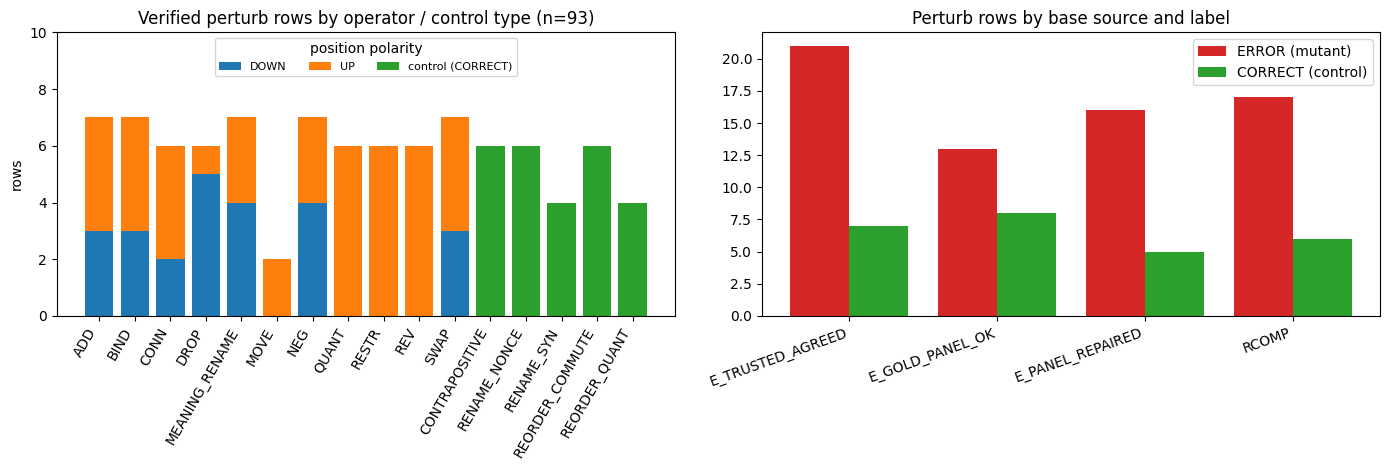

In [15]:
all_groups = {**{g["dataset"]: g["examples"] for g in groups}, "adjudicator_check": G["adjudicator_check"]}
print(f"{'group':<20}{'rows':>6}{'verified':>10}{'failed':>8}")
for name, exs in all_groups.items():
    ok = sum(e["metadata_source_verified"] for e in exs)
    print(f"{name:<20}{len(exs):>6}{ok:>10}{len(exs) - ok:>8}")
print("\nsource_verification counters:", dict(stats))
print("\nrows per traced source file:")
for sf, c in Counter(e["metadata_source_file"] for exs in all_groups.values() for e in exs).most_common():
    print(f"  {c:>4}  {sf}")

P = G["perturb_suite"]
print("\nExample rows (sentence -> reference -> candidate):")
shown = set()
for e in P:
    k = e.get("metadata_operator") or e.get("metadata_subtype")
    if k in shown or len(shown) >= 6:
        continue
    shown.add(k)
    inp = json.loads(e["input"])
    print(f"\n[{e['output']}] {inp['system']}  (base: {e['metadata_base_source']}, verified={e['metadata_source_verified']})")
    print("  text:     ", inp["text"][:160])
    print("  reference:", inp["reference_fol"][:160])
    print("  candidate:", inp["candidate_fol"][:160])
for e in G["rcomp_sentences"][:1]:
    inp = json.loads(e["input"])
    print(f"\n[R_COMP {e['metadata_template_id']}, {e['metadata_strata']['words']} words, "
          f"{e['metadata_strata']['n_conditions']} conditions] {inp['text']}")
    print("  weak:  ", inp["reference_fol_weak"])
    print("  strong:", inp["reference_fol_strong"])

# ---- plots
kinds = [e.get("metadata_operator") or e.get("metadata_subtype") for e in P]
labels = sorted(set(kinds), key=lambda k: (k not in {e.get("metadata_operator") for e in P}, k))
pol = {k: Counter(e.get("metadata_position_polarity") or "control" for e, kk in zip(P, kinds) if kk == k) for k in labels}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
bottom = np.zeros(len(labels))
for p, col in (("DOWN", "#1f77b4"), ("UP", "#ff7f0e"), ("control", "#2ca02c")):
    vals = np.array([pol[k].get(p, 0) for k in labels])
    axes[0].bar(labels, vals, bottom=bottom, color=col, label=p if p != "control" else "control (CORRECT)")
    bottom += vals
axes[0].set_title(f"Verified perturb rows by operator / control type (n={len(P)})")
axes[0].set_ylabel("rows")
plt.setp(axes[0].get_xticklabels(), rotation=60, ha="right")
axes[0].set_ylim(0, bottom.max() + 3)
axes[0].legend(title="position polarity", ncol=3, loc="upper center", fontsize=8)
src_order = ["E_TRUSTED_AGREED", "E_GOLD_PANEL_OK", "E_PANEL_REPAIRED", "RCOMP"]
out_c = {s: Counter(e["output"] for e in P if e["metadata_base_source"] == s) for s in src_order}
x = np.arange(len(src_order))
axes[1].bar(x - 0.2, [out_c[s].get("ERROR", 0) for s in src_order], 0.4, label="ERROR (mutant)", color="#d62728")
axes[1].bar(x + 0.2, [out_c[s].get("CORRECT", 0) for s in src_order], 0.4, label="CORRECT (control)", color="#2ca02c")
axes[1].set_xticks(x, src_order, rotation=20, ha="right")
axes[1].set_title("Perturb rows by base source and label")
axes[1].legend()
plt.tight_layout()
plt.show()